<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/Santos_FA12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ANALYSIS OF VARIANCE (TWO-WAY ANOVA)
Dependent Variable: Yield

                         sum_sq    df         F  PR(>F)  eta_sq
Intercept              91665.80   1.0  207.3457  0.0000  0.7107
C(Fertilizer)           3734.80   2.0    4.2240  0.0204  0.0290
C(Crop)                 6125.35   3.0    4.6185  0.0064  0.0475
C(Fertilizer):C(Crop)   6225.90   6.0    2.3471  0.0456  0.0483
Residual               21220.40  48.0       NaN     NaN  0.1645

ASSUMPTION CHECKS
Shapiro-Wilk Test: W = 0.9803, p = 0.4402
Levene’s Test: W = 0.6746, p = 0.7551

DESCRIPTIVE STATISTICS (MEANS)
Crop         Corn   Rice    Soy  Wheat
Fertilizer                            
X           135.4  141.2  175.8  131.8
Y           159.6  165.4  140.2  143.2
Z           173.6  172.4  186.4  164.4


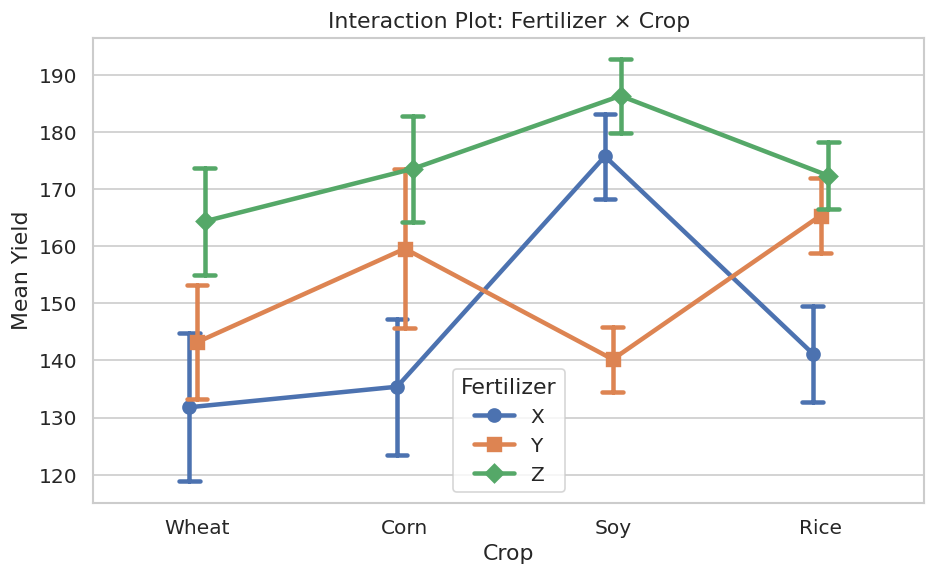

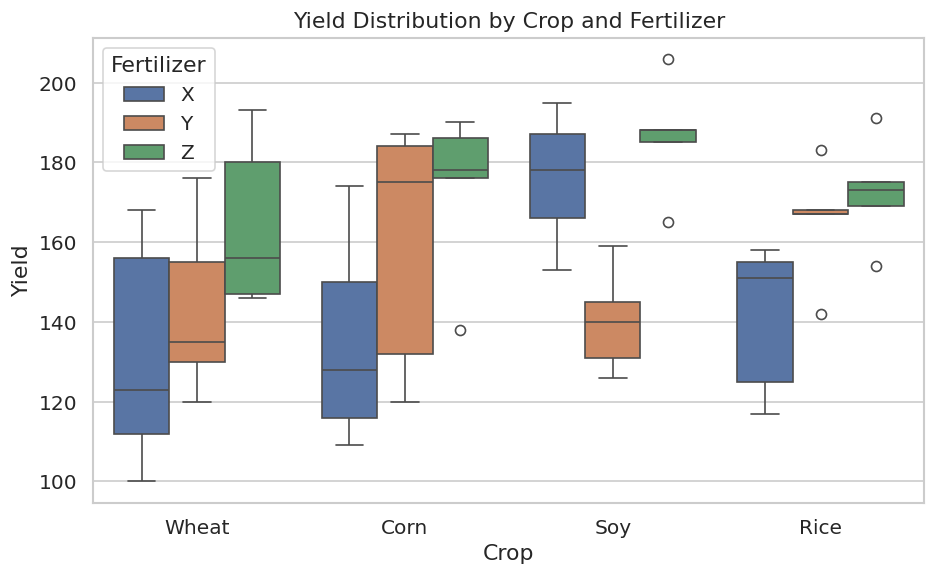

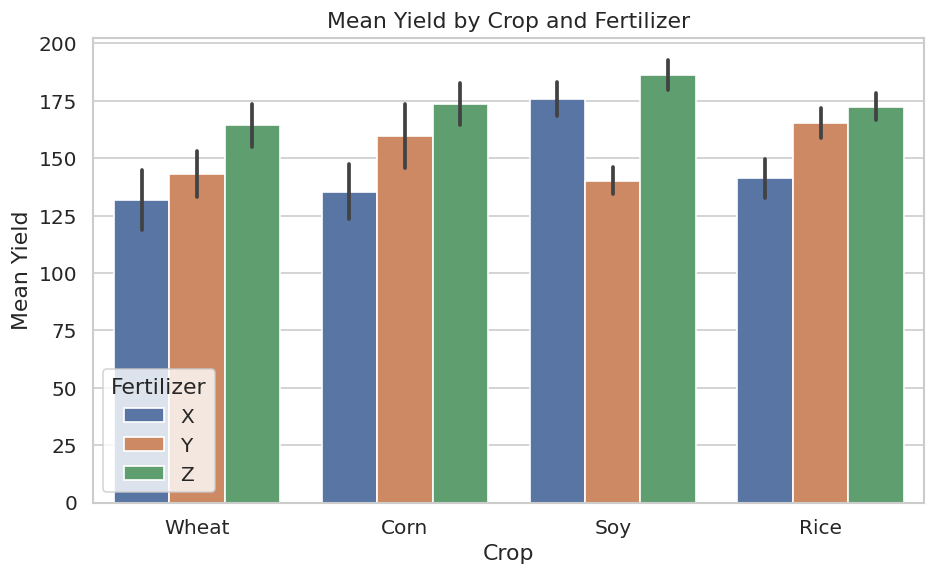


POST HOC TEST (Tukey HSD)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj   lower    upper   reject
--------------------------------------------------------
 X_Corn  X_Rice      5.8    1.0 -39.8617  51.4617  False
 X_Corn   X_Soy     40.4  0.129  -5.2617  86.0617  False
 X_Corn X_Wheat     -3.6    1.0 -49.2617  42.0617  False
 X_Corn  Y_Corn     24.2 0.7992 -21.4617  69.8617  False
 X_Corn  Y_Rice     30.0 0.5199 -15.6617  75.6617  False
 X_Corn   Y_Soy      4.8    1.0 -40.8617  50.4617  False
 X_Corn Y_Wheat      7.8    1.0 -37.8617  53.4617  False
 X_Corn  Z_Corn     38.2 0.1837  -7.4617  83.8617  False
 X_Corn  Z_Rice     37.0 0.2201  -8.6617  82.6617  False
 X_Corn   Z_Soy     51.0 0.0169   5.3383  96.6617   True
 X_Corn Z_Wheat     29.0 0.5706 -16.6617  74.6617  False
 X_Rice   X_Soy     34.6 0.3072 -11.0617  80.2617  False
 X_Rice X_Wheat     -9.4 0.9999 -55.0617  36.2617  False
 X_Rice  Y_Corn     18.4 0.9612 -27.2617  64.0617  False
 X_R

In [2]:
!pip install statsmodels seaborn scipy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

data = []
crops = ["Wheat", "Corn", "Soy", "Rice"]

blend_X = [
    [123,128,166,151],
    [156,150,178,125],
    [112,174,187,117],
    [100,116,153,155],
    [168,109,195,158]
]

blend_Y = [
    [135,175,140,167],
    [130,132,145,183],
    [176,120,159,142],
    [120,187,131,167],
    [155,184,126,168]
]

blend_Z = [
    [156,186,185,175],
    [180,138,206,173],
    [147,178,188,154],
    [146,176,165,191],
    [193,190,188,169]
]

def add_data(blend, rows):
    for row in rows:
        for i, val in enumerate(row):
            data.append([blend, crops[i], val])

add_data("X", blend_X)
add_data("Y", blend_Y)
add_data("Z", blend_Z)

df = pd.DataFrame(data, columns=["Fertilizer", "Crop", "Yield"])

model = ols('Yield ~ C(Fertilizer) * C(Crop)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=3)

anova_table["eta_sq"] = anova_table["sum_sq"] / sum(anova_table["sum_sq"])

print("\nANALYSIS OF VARIANCE (TWO-WAY ANOVA)")
print("Dependent Variable: Yield\n")
print(anova_table[["sum_sq", "df", "F", "PR(>F)", "eta_sq"]].round(4))

shapiro_stat, shapiro_p = shapiro(model.resid)

groups = [g["Yield"].values for _, g in df.groupby(["Fertilizer","Crop"])]
levene_stat, levene_p = levene(*groups)

print("\nASSUMPTION CHECKS")
print(f"Shapiro-Wilk Test: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
print(f"Levene’s Test: W = {levene_stat:.4f}, p = {levene_p:.4f}")

means = df.groupby(['Fertilizer','Crop'])['Yield'].mean().unstack()

print("\nDESCRIPTIVE STATISTICS (MEANS)")
print(means.round(2))

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df,
    x='Crop',
    y='Yield',
    hue='Fertilizer',
    dodge=True,
    markers=['o','s','D'],
    capsize=0.1,
    errorbar='se'
)

plt.title("Interaction Plot: Fertilizer × Crop")
plt.ylabel("Mean Yield")
plt.xlabel("Crop")
plt.legend(title="Fertilizer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Crop',
    y='Yield',
    hue='Fertilizer'
)

plt.title("Yield Distribution by Crop and Fertilizer")
plt.ylabel("Yield")
plt.xlabel("Crop")
plt.legend(title="Fertilizer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Crop',
    y='Yield',
    hue='Fertilizer',
    errorbar='se'
)

plt.title("Mean Yield by Crop and Fertilizer")
plt.ylabel("Mean Yield")
plt.xlabel("Crop")
plt.legend(title="Fertilizer")
plt.tight_layout()
plt.show()

df["Group"] = df["Fertilizer"] + "_" + df["Crop"]
tukey = pairwise_tukeyhsd(df["Yield"], df["Group"])

print("\nPOST HOC TEST (Tukey HSD)")
print(tukey)

alpha = 0.05

print("\nSTATISTICAL DECISION")

p_fert = anova_table.loc["C(Fertilizer)", "PR(>F)"]
p_crop = anova_table.loc["C(Crop)", "PR(>F)"]
p_int = anova_table.loc["C(Fertilizer):C(Crop)", "PR(>F)"]

print("\nFertilizer Effect:")
if p_fert < alpha:
    print(f"p = {p_fert:.4f} < 0.05 → Reject H₀. Fertilizer has a significant effect on yield.")
else:
    print(f"p = {p_fert:.4f} ≥ 0.05 → Fail to reject H₀. Fertilizer has no significant effect on yield.")

print("\nCrop Effect:")
if p_crop < alpha:
    print(f"p = {p_crop:.4f} < 0.05 → Reject H₀. Crop type has a significant effect on yield.")
else:
    print(f"p = {p_crop:.4f} ≥ 0.05 → Fail to reject H₀. Crop type has no significant effect on yield.")

print("\nInteraction Effect (Fertilizer × Crop):")
if p_int < alpha:
    print(f"p = {p_int:.4f} < 0.05 → Reject H₀. There is a significant interaction effect.")
else:
    print(f"p = {p_int:.4f} ≥ 0.05 → Fail to reject H₀. No significant interaction effect.")

print("\nASSUMPTION CHECK SUMMARY")

print("Normality of residuals:", "Met" if shapiro_p > 0.05 else "Violated")
print("Homogeneity of variance:", "Met" if levene_p > 0.05 else "Violated")